# トップリバー：予測モデル作成

In [1]:
import os
import numpy as np
import pandas as pd
from scipy.optimize import curve_fit
import matplotlib.pyplot as plt
from pycaret.regression import *
from sklearn.metrics import r2_score, mean_absolute_percentage_error

In [2]:
### 変数設定 ###
#--ファイル
farm_list = "farm/topriver_farm.csv"
farm_data = "farm/topriver_data.csv"
farm_data_2025 = "farm/topriver_data_2025.csv"
remove_list = "farm/topriver_remove_list.csv"
weather_file = "weather/topriver/weather_{}.csv"
# model_data = "farm/topriver_model_data.csv"
model_data = "farm/topriver_model_data_2025.csv"

## モデル学習
- PyCaretを用いたMLモデルの学習を行う

In [4]:
### データ読み込み ###
#--ML学習用データセット読み込み
df_ml = pd.read_csv(model_data)

# #--2024年をテストデータとする場合、2025年は除外しておく
# df_ml = df_ml.query("年度 != 2025").reset_index(drop=True)

In [5]:
### 追加の前処理 ###
#--品種ごとの平均的な栽培日数（テストデータの年を除く）
# 自らの年度を含まずに栽培日数の平均値を求める
# test_year = 2024
test_year = 2025

df_stats = pd.DataFrame()
for y in df_ml['年度'].unique():
    df = (df_ml
        .query("年度 != @test_year")
        .query("年度 != @y")
        .drop_duplicates(subset=['栽培グループ名','年度','圃場名'])
        .groupby('栽培グループ名')
        .aggregate({'栽培日数':['mean','std']})
    ).round(1)
    df.columns = ['grow_days_mean', 'grow_days_std']
    df['年度'] = y
    df_stats = pd.concat([df_stats, df])

df_ml = pd.merge(df_ml, df_stats.fillna(0), on=['栽培グループ名','年度'], how='left')
df_ml['remain_days'] = (df_ml['grow_days_mean'] - df_ml['経過日']).round(2)

#--経過日=0日だと気象要素の平均値が定義できないためNaNになっている→ゼロで補完
df_ml.fillna(0, inplace=True)

In [6]:
### 学習前準備 ###
# #--カラム名一覧表示
# for i in range(len(df_ml.columns)//10 + 1):
#     print(df_ml.columns[i*10:(i+1)*10].tolist())

#--目的変数と説明変数の設定
target_col = 'Target_Days'
feature_cols = [
    '経過日', 'NDVI値', 'remain_NDVI', 
    'TMP_mea', 'APCPRA', 'GSR', 'TMP_GDD2', 'TMP_GDD5', 'TmulGSR', 'RA_days', 
    'TMP_mea_05', 'APCPRA_05', 'GSR_05', 'TMP_GDD2_05', 'TMP_GDD5_05', 'TmulGSR_05', 'RA_days_05',
    'TMP_mea_10', 'APCPRA_10', 'GSR_10', 'TMP_GDD2_10', 'TMP_GDD5_10', 'TmulGSR_10', 'RA_days_10',
    'TMP_mea_15', 'APCPRA_15', 'GSR_15', 'TMP_GDD2_15', 'TMP_GDD5_15', 'TmulGSR_15', 'RA_days_15',
    'TMP_mea_20', 'APCPRA_20', 'GSR_20', 'TMP_GDD2_20', 'TMP_GDD5_20', 'TmulGSR_20', 'RA_days_20',
    'TMP_mea_25', 'APCPRA_25', 'GSR_25', 'TMP_GDD2_25', 'TMP_GDD5_25', 'TmulGSR_25', 'RA_days_25',
    'TMP_mea_30', 'APCPRA_30', 'GSR_30', 'TMP_GDD2_30', 'TMP_GDD5_30', 'TmulGSR_30', 'RA_days_30',
    'planting_month', 'grow_days_mean', 'grow_days_std', 'remain_days',
    'TMP_max', 'RH_ave', 
    'TMP_max_05', 'RH_ave_05', 'TMP_max_10', 'RH_ave_10', 
    'TMP_max_15', 'RH_ave_15', 'TMP_max_20', 'RH_ave_20', 
    'TMP_max_25', 'RH_ave_25', 'TMP_max_30', 'RH_ave_30',  
]
ignore_cols = [col for col in df_ml.columns if col not in feature_cols + [target_col]]
print(f'Feature cols: {len(feature_cols)}, Ignore cols: {len(ignore_cols)}')

categorical_cols = ['planting_month']
for col in categorical_cols:
    df_ml[col] = pd.Categorical(df_ml[col])

#--Train/Test Split
TRAIN = df_ml.query("年度 != @test_year").reset_index(drop=True)
TEST = df_ml.query("年度 == @test_year").reset_index(drop=True)
print(f'Train samples: {TRAIN.shape[0]}, Test samples: {TEST.shape[0]}')

#--PyCaretのフレームワークでは存在しないカラム名を入れても明示的にエラーにならない
#--念のためカラム名に間違いないか確認したい場合、以下を実行してエラーが出なければOK
# X_train = TRAIN[feature_cols]
# y_train = TRAIN[target_col]
# X_test = TEST[feature_cols]
# y_test = TEST[target_col]

Feature cols: 70, Ignore cols: 102
Train samples: 7786, Test samples: 1138


In [7]:
#--PyCaretのセットアップ
groups = TRAIN['年度']
fold_num = TRAIN['年度'].nunique()

reg = setup(
    data = TRAIN,
    target = target_col,
    ignore_features = ignore_cols,
    categorical_features = categorical_cols,
    session_id = 42,
    fold_strategy='groupkfold',
    fold_groups=groups,
    fold=fold_num,
    data_split_shuffle=False,
    fold_shuffle=False,
    verbose=False,
    n_jobs = -1
)

In [7]:
### MLモデル学習 ###
#--複数のアルゴリズム比較
# best = compare_models()

In [8]:
#--Lasso回帰モデル作成
print("Lasso回帰")
model_lasso = create_model('lasso')

#--Bayesian Ridge回帰モデル作成
print("Bayesian Ridge")
model_br = create_model('br')

#--Extra Tree Regressorモデル作成
print("Extra Tree Regressor")
model_etr = create_model('et')

#--ランダムフォレストモデル作成
print("Random Forest")
model_rfr = create_model('rf')

#--LightGBMモデル作成
print("LightGBM")
model_lgbm = create_model('lightgbm')

#--CatBoostモデル作成
print("CatBoost")
model_cat = create_model('catboost')

Lasso回帰


,MAE,MSE,RMSE,R2,RMSLE,MAPE
Fold,,,,,,
0,2.7860,12.5516,3.5428,0.9491,0.2783,0.2149
1,2.7174,15.9923,3.9990,0.9339,0.3816,0.2719
2,2.8671,12.8115,3.5793,0.9372,0.3417,0.2917
3,2.2942,8.7285,2.9544,0.9680,0.3698,0.2867
4,2.8025,13.4529,3.6678,0.9509,0.3529,0.2927
5,2.9589,11.8457,3.4418,0.9566,0.3956,0.2975
6,2.2029,8.1420,2.8534,0.9635,0.3480,0.3045
Mean,2.6613,11.9321,3.4341,0.9513,0.3526,0.2800
Std,0.2711,2.5239,0.3730,0.0117,0.0352,0.0282


Bayesian Ridge


,MAE,MSE,RMSE,R2,RMSLE,MAPE
Fold,,,,,,
0,3.3683,16.6103,4.0756,0.9326,0.3503,0.2524
1,2.8024,17.3379,4.1639,0.9284,0.4035,0.2911
2,2.9816,13.8041,3.7154,0.9323,0.3487,0.2953
3,2.4284,9.3453,3.0570,0.9657,0.3824,0.3087
4,2.8850,14.0305,3.7457,0.9488,0.3761,0.3115
5,3.0466,12.6797,3.5609,0.9536,0.3855,0.2939
6,2.2939,8.6425,2.9398,0.9613,0.3377,0.3270
Mean,2.8295,13.2072,3.6083,0.9461,0.3692,0.2971
Std,0.3406,3.0638,0.4327,0.0140,0.0221,0.0216


Extra Tree Regressor


...

,MAE,MSE,RMSE,R2,RMSLE,MAPE
Fold,,,,,,
0,2.9882,14.0313,3.7458,0.9431,0.2496,0.1821
1,2.4136,13.4402,3.6661,0.9445,0.2993,0.1877
2,2.6676,11.6878,3.4187,0.9427,0.3285,0.2490
3,2.3935,9.2922,3.0483,0.9659,0.3302,0.2447
4,2.9367,15.8700,3.9837,0.9421,0.3782,0.2535
5,2.9198,12.1438,3.4848,0.9555,0.3620,0.2817
6,2.7198,11.7990,3.4350,0.9472,0.3673,0.3224
Mean,2.7199,12.6092,3.5403,0.9487,0.3307,0.2459
Std,0.2274,1.9298,0.2740,0.0082,0.0417,0.0458


LightGBM


,MAE,MSE,RMSE,R2,RMSLE,MAPE
Fold,,,,,,
0,2.8956,13.2096,3.6345,0.9464,0.2540,0.1871
1,2.5241,14.5984,3.8208,0.9397,0.3091,0.1752
2,2.6601,12.1958,3.4922,0.9402,0.3153,0.2325
3,2.5563,10.3857,3.2227,0.9619,0.3284,0.2343
4,3.1076,17.4107,4.1726,0.9364,0.3853,0.2576
5,2.8474,12.0034,3.4646,0.9561,0.3355,0.2429
6,2.7223,11.8467,3.4419,0.9470,0.3549,0.3111
Mean,2.7591,13.0929,3.6070,0.9468,0.3261,0.2344
Std,0.1910,2.1313,0.2866,0.0086,0.0378,0.0418


CatBoost


,MAE,MSE,RMSE,R2,RMSLE,MAPE
Fold,,,,,,
0,2.8404,13.0709,3.6154,0.9470,0.2550,0.1792
1,2.5825,14.2978,3.7812,0.9409,0.3327,0.1992
2,2.5466,11.0861,3.3296,0.9457,0.3141,0.2210
3,2.3353,8.8951,2.9825,0.9674,0.3184,0.2312
4,2.9522,16.3069,4.0382,0.9405,0.4018,0.2550
5,2.7532,11.1827,3.3440,0.9591,0.3249,0.2345
6,2.8220,11.7839,3.4328,0.9472,0.3576,0.3413
Mean,2.6903,12.3748,3.5034,0.9497,0.3292,0.2373
Std,0.1967,2.2419,0.3180,0.0092,0.0413,0.0482


In [9]:
#--ハイパーパラメータのチューニング
print("Lasso回帰")
tuned_lasso = tune_model(model_lasso, n_iter=50, optimize='MAE')
print("Bayesian Ridge")
tuned_br = tune_model(model_br, n_iter=50, optimize='MAE')
print("Extra Tree Regressor")
tuned_etr = tune_model(model_etr, n_iter=50, optimize='MAE')
print("Random Forest")
tuned_rfr = tune_model(model_rfr, n_iter=50, optimize='MAE')
print("LightGBM")
tuned_lgbm = tune_model(model_lgbm, n_iter=50, optimize='MAE')
print("CatBoost")
tuned_cat = tune_model(model_cat, n_iter=50, optimize='MAE')

Lasso回帰


,MAE,MSE,RMSE,R2,RMSLE,MAPE
Fold,,,,,,
0,2.8522,12.9879,3.6039,0.9473,0.2887,0.2195
1,2.6924,15.7823,3.9727,0.9348,0.3729,0.2665
2,2.8552,12.6797,3.5609,0.9378,0.3426,0.2931
3,2.2723,8.5932,2.9314,0.9685,0.3685,0.2830
4,2.7880,13.3498,3.6537,0.9513,0.3535,0.2920
5,2.9414,11.6525,3.4136,0.9573,0.3928,0.2954
6,2.2287,8.2956,2.8802,0.9629,0.3466,0.3053
Mean,2.6614,11.9059,3.4309,0.9514,0.3522,0.2793
Std,0.2694,2.4771,0.3670,0.0116,0.0305,0.0268


Fitting 7 folds for each of 50 candidates, totalling 350 fits
Original model was better than the tuned model, hence it will be returned. NOTE: The display metrics are for the tuned model (not the original one).
Bayesian Ridge


,MAE,MSE,RMSE,R2,RMSLE,MAPE
Fold,,,,,,
0,3.3695,16.6213,4.0769,0.9326,0.3508,0.2525
1,2.6836,16.6506,4.0805,0.9312,0.3974,0.2755
2,2.9829,13.8150,3.7168,0.9323,0.3489,0.2954
3,2.4255,9.3253,3.0537,0.9658,0.3818,0.3084
4,2.8858,14.0487,3.7482,0.9487,0.3770,0.3114
5,3.0440,12.6673,3.5591,0.9536,0.3854,0.2936
6,2.2942,8.6464,2.9405,0.9613,0.3378,0.3270
Mean,2.8122,13.1107,3.5965,0.9465,0.3684,0.2948
Std,0.3450,2.9444,0.4190,0.0135,0.0208,0.0229


Fitting 7 folds for each of 50 candidates, totalling 350 fits
Extra Tree Regressor


...

Fitting 7 folds for each of 50 candidates, totalling 350 fits
LightGBM


,MAE,MSE,RMSE,R2,RMSLE,MAPE
Fold,,,,,,
0,2.9416,13.8833,3.7260,0.9437,0.2543,0.1827
1,2.5038,14.1571,3.7626,0.9415,0.2928,0.1810
2,2.6039,11.4250,3.3801,0.9440,0.3061,0.2161
3,2.5223,10.1257,3.1821,0.9629,0.3269,0.2417
4,2.8819,15.3629,3.9196,0.9439,0.3766,0.2504
5,2.8119,11.4551,3.3845,0.9581,0.3550,0.2578
6,2.6165,11.2126,3.3485,0.9498,0.3429,0.3060
Mean,2.6974,12.5174,3.5291,0.9491,0.3221,0.2337
Std,0.1648,1.7887,0.2512,0.0077,0.0382,0.0411


Fitting 7 folds for each of 50 candidates, totalling 350 fits
CatBoost


,MAE,MSE,RMSE,R2,RMSLE,MAPE
Fold,,,,,,
0,3.0740,14.6740,3.8307,0.9405,0.2688,0.2070
1,2.4292,13.3529,3.6542,0.9448,0.3267,0.1990
2,2.5525,10.9639,3.3112,0.9463,0.3293,0.2371
3,2.4033,9.2415,3.0400,0.9661,0.3415,0.2457
4,2.7792,14.2621,3.7765,0.9479,0.3737,0.2649
5,2.6529,10.0226,3.1658,0.9633,0.3718,0.2696
6,2.5566,10.5490,3.2479,0.9528,0.3651,0.3154
Mean,2.6354,11.8666,3.4323,0.9517,0.3395,0.2484
Std,0.2148,2.0239,0.2928,0.0089,0.0341,0.0369


Fitting 7 folds for each of 50 candidates, totalling 350 fits


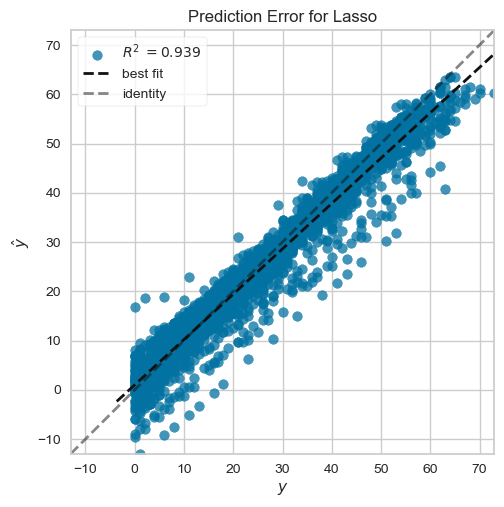

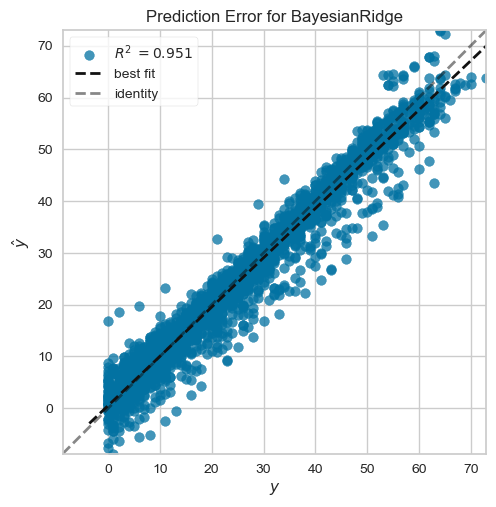

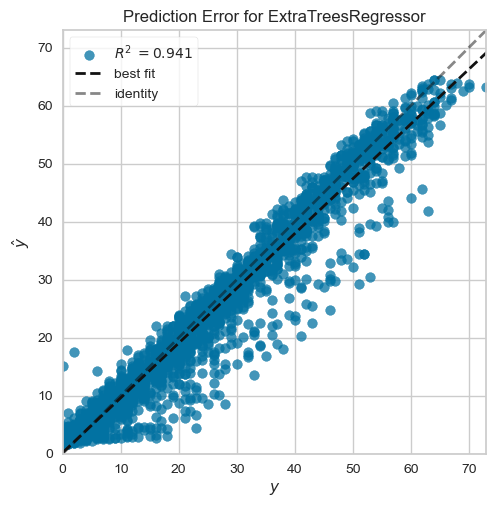

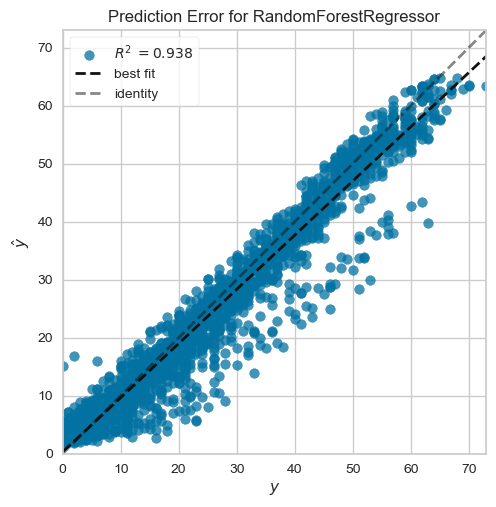

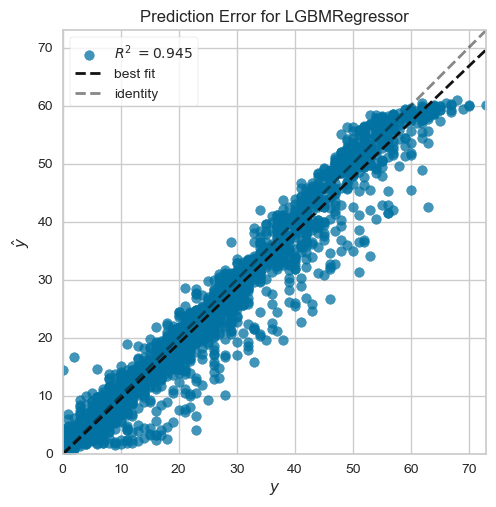

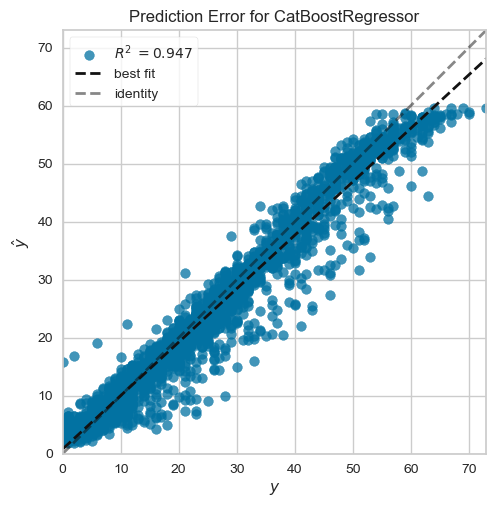

In [10]:
#--予測誤差プロット
plot_model(tuned_lasso, plot='error')
plot_model(tuned_br, plot='error')
plot_model(tuned_etr, plot='error')
plot_model(tuned_rfr, plot='error')
plot_model(tuned_lgbm, plot='error')
plot_model(tuned_cat, plot='error')

In [11]:
#--最終モデルの確定
final_lasso = finalize_model(tuned_lasso)
final_br = finalize_model(tuned_br)
final_etr = finalize_model(tuned_etr)
final_rfr = finalize_model(tuned_rfr)
final_lgbm = finalize_model(tuned_lgbm)
final_cat = finalize_model(tuned_cat)

In [8]:
### 追加クレンジング ###
# テストデータを使った予測テストを行ったところ、明らかに異常なデータが１つ見つかった
# 御代田地区：ルシナ66 の 事務所上 の圃場について、栽培期間が明らかに短すぎる
# そのため、当該データは削除して予測テスト結果を示す
TEST = TEST.query("not (栽培グループ名 == '御代田地区：ルシナ66' and 圃場名 == '事務所上')").reset_index(drop=True)

In [9]:
#--テストデータで予測・評価（収穫日まで30日以内）
print("Lasso回帰")
pred_lasso = predict_model(final_lasso, data=TEST.query("Target_Days <= 30"))
print("Bayesian Ridge")
pred_br = predict_model(final_br, data=TEST.query("Target_Days <= 30"))
print("Extra Tree Regressor")
pred_etr = predict_model(final_etr, data=TEST.query("Target_Days <= 30"))
print("Random Forest")
pred_rfr = predict_model(final_rfr, data=TEST.query("Target_Days <= 30"))
print("LightGBM")
pred_lgbm = predict_model(final_lgbm, data=TEST.query("Target_Days <= 30"))
print("CatBoost")
pred_cat = predict_model(final_cat, data=TEST.query("Target_Days <= 30"))

Lasso回帰


,Model,MAE,MSE,RMSE,R2,RMSLE,MAPE
0,Lasso Regression,2.4987,10.3345,3.2147,0.8717,0.3767,0.2970


Bayesian Ridge


,Model,MAE,MSE,RMSE,R2,RMSLE,MAPE
0,Bayesian Ridge,2.5341,12.7285,3.5677,0.8420,0.3690,0.2721


Extra Tree Regressor


...

,Model,MAE,MSE,RMSE,R2,RMSLE,MAPE
0,Random Forest Regressor,2.2771,8.3972,2.8978,0.8958,0.3688,0.2710


LightGBM


,Model,MAE,MSE,RMSE,R2,RMSLE,MAPE
0,Light Gradient Boosting Machine,2.3460,10.4223,3.2284,0.8706,0.3659,0.2548


[LightGBM] [Warning] bagging_freq is set=5, subsample_freq=0 will be ignored. Current value: bagging_freq=5
[LightGBM] [Warning] feature_fraction is set=0.8, colsample_bytree=1.0 will be ignored. Current value: feature_fraction=0.8
[LightGBM] [Warning] bagging_fraction is set=0.6, subsample=1.0 will be ignored. Current value: bagging_fraction=0.6
CatBoost


,Model,MAE,MSE,RMSE,R2,RMSLE,MAPE
0,CatBoost Regressor,2.5305,11.2022,3.3470,0.8609,0.3809,0.2830


In [10]:
#--テストデータで予測・評価
print("Lasso回帰")
pred_lasso = predict_model(final_lasso, data=TEST)
print("Bayesian Ridge")
pred_br = predict_model(final_br, data=TEST)
print("Extra Tree Regressor")
pred_etr = predict_model(final_etr, data=TEST)
print("Random Forest")
pred_rfr = predict_model(final_rfr, data=TEST)
print("LightGBM")
pred_lgbm = predict_model(final_lgbm, data=TEST)
print("CatBoost")
pred_cat = predict_model(final_cat, data=TEST)

Lasso回帰


,Model,MAE,MSE,RMSE,R2,RMSLE,MAPE
0,Lasso Regression,2.4682,9.5623,3.0923,0.9588,0.2877,0.1928


Bayesian Ridge


,Model,MAE,MSE,RMSE,R2,RMSLE,MAPE
0,Bayesian Ridge,2.5334,11.8744,3.4459,0.9489,0.2828,0.1801


Extra Tree Regressor


...

,Model,MAE,MSE,RMSE,R2,RMSLE,MAPE
0,Random Forest Regressor,2.3025,8.3601,2.8914,0.9640,0.2817,0.1772


LightGBM


,Model,MAE,MSE,RMSE,R2,RMSLE,MAPE
0,Light Gradient Boosting Machine,2.3697,10.3801,3.2218,0.9553,0.2804,0.1690


[LightGBM] [Warning] bagging_freq is set=5, subsample_freq=0 will be ignored. Current value: bagging_freq=5
[LightGBM] [Warning] feature_fraction is set=0.8, colsample_bytree=1.0 will be ignored. Current value: feature_fraction=0.8
[LightGBM] [Warning] bagging_fraction is set=0.6, subsample=1.0 will be ignored. Current value: bagging_fraction=0.6
CatBoost


,Model,MAE,MSE,RMSE,R2,RMSLE,MAPE
0,CatBoost Regressor,2.4630,10.4584,3.2339,0.9550,0.2911,0.1845


In [15]:
#--Lasso回帰の回帰係数をチェック
# reg = setup(
#     data = TRAIN,
#     target = target_col,
#     ignore_features = ignore_cols,
#     categorical_features = categorical_cols,
#     verbose=False,
#     session_id = 42,
# )

coef = final_lasso.coef_
intercept = final_lasso.intercept_
feature_names = get_config('X_train_transformed').columns

# DataFrameを作成
lasso_coef = pd.DataFrame({
    'Feature': np.append(feature_names, 'Intercept'),
    'Coefficient': np.append(coef, intercept)
})
display(lasso_coef.query("Coefficient != 0"))

,Feature,Coefficient
3,TMP_mea,-0.035852
4,TMP_max,-0.042399
6,GSR,-0.000149
7,TMP_GDD2,0.015746
8,TMP_GDD5,0.002576
9,TmulGSR,0.005876
11,RH_ave,0.005200
18,TmulGSR_05,-0.000326
20,RH_ave_05,0.005434
27,TmulGSR_10,-0.000241


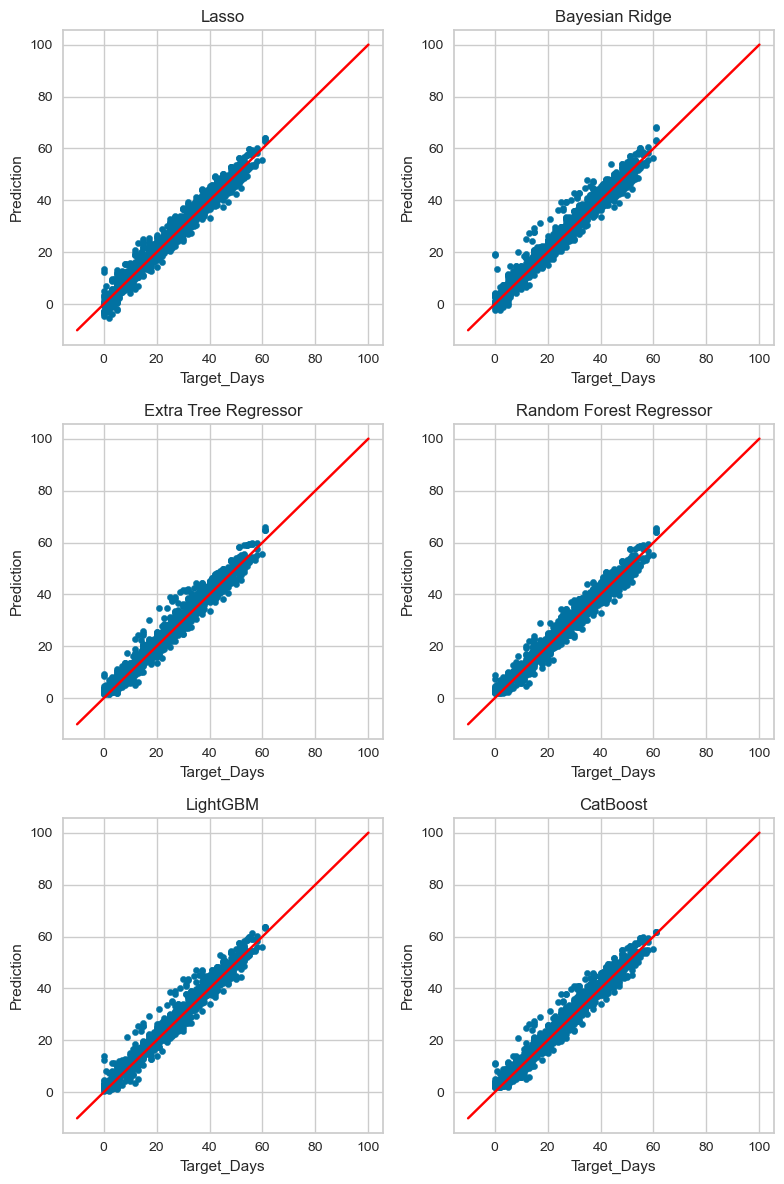

In [11]:
#--予測結果の散布図表示
result = [pred_lasso, pred_br, pred_etr, pred_rfr, pred_lgbm, pred_cat]
model_names = ['Lasso', 'Bayesian Ridge', 'Extra Tree Regressor', 'Random Forest Regressor', 'LightGBM', 'CatBoost']

fig = plt.figure(figsize=(8,12))
for model, result in zip(model_names, result):
    ax = fig.add_subplot(3, 2, model_names.index(model)+1)
    result.plot.scatter(x='Target_Days', y='prediction_label', ax=ax)
    ax.plot([-10,100], [-10,100], color='red')
    ax.set_ylabel('Prediction')
    ax.set_title(model)
plt.tight_layout()
plt.show()

,MAE,RMSE,R2,MAPE
0,2.705981,3.258055,0.954313,2.523125e+14


,MAE,RMSE,R2,MAPE
0,2.80387,3.355664,0.860215,4.440856e+14


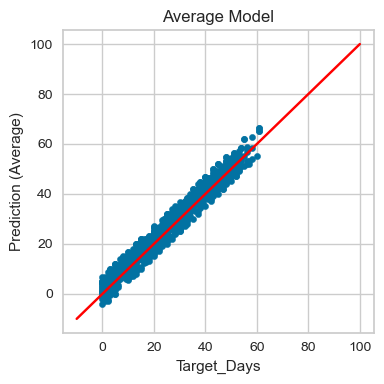

In [12]:
### 過去平均値モデル (ベンチマーク) ###
#--過去の平均値で予測
df_ave_model = pd.DataFrame({
    "MAE":[((TEST['remain_days'] - TEST['Target_Days']).abs()).mean()],
    "RMSE":[np.sqrt(((TEST['remain_days'] - TEST['Target_Days'])**2).mean())],
    "R2":[r2_score(TEST['Target_Days'], TEST['remain_days'])],
    "MAPE": [mean_absolute_percentage_error(TEST['Target_Days'], TEST['remain_days'])]
})
display(df_ave_model)

#--収穫日30日以内に絞った場合
TEST30 = TEST.query("Target_Days <= 30")
df_ave_model30 = pd.DataFrame({
    "MAE":[((TEST30['remain_days'] - TEST30['Target_Days']).abs()).mean()],
    "RMSE":[np.sqrt(((TEST30['remain_days'] - TEST30['Target_Days'])**2).mean())],
    "R2":[r2_score(TEST30['Target_Days'], TEST30['remain_days'])],
    "MAPE": [mean_absolute_percentage_error(TEST30['Target_Days'], TEST30['remain_days'])]
})
display(df_ave_model30)

#--散布図で可視化
fig = plt.figure(figsize=(4,4))
ax = fig.add_subplot(1, 1, 1)
TEST.plot.scatter(x='Target_Days', y='remain_days', ax=ax)
ax.plot([-10,100], [-10,100], color='red')
ax.set_ylabel('Prediction (Average)')
ax.set_title('Average Model')
plt.tight_layout()
plt.show()

In [13]:
#--MAPEのみTarget＿Days=0を除外して計算
df = TEST.query("Target_Days != 0")
print(((df['Target_Days'] - df['remain_days']).abs()/df['Target_Days']).mean())
df = TEST30.query("Target_Days != 0")
print(((df['Target_Days'] - df['remain_days']).abs()/df['Target_Days']).mean())

0.23294074785653754
0.3656868304105706


In [ ]:
#--学習済みモデルの保存
save_dir = f"model/{test_year}_ex"
os.makedirs(save_dir, exist_ok=True)

save_model(final_lasso, f"{save_dir}/topriver_lasso_model")
save_model(final_br, f"{save_dir}/topriver_br_model")
save_model(final_etr, f"{save_dir}/topriver_etr_model")
save_model(final_rfr, f"{save_dir}/topriver_rfr_model")
save_model(final_lgbm, f"{save_dir}/topriver_lgbm_model")
save_model(final_cat, f"{save_dir}/topriver_cat_model")

Transformation Pipeline and Model Successfully Saved
Transformation Pipeline and Model Successfully Saved
Transformation Pipeline and Model Successfully Saved
Transformation Pipeline and Model Successfully Saved
Transformation Pipeline and Model Successfully Saved
Transformation Pipeline and Model Successfully Saved


(Pipeline(memory=Memory(location=None),
          steps=[('numerical_imputer',
                  TransformerWrapper(include=['経過日', 'NDVI値', 'remain_NDVI',
                                              'TMP_mea', 'TMP_max', 'APCPRA',
                                              'GSR', 'TMP_GDD2', 'TMP_GDD5',
                                              'TmulGSR', 'RA_days', 'RH_ave',
                                              'TMP_mea_05', 'TMP_max_05',
                                              'APCPRA_05', 'GSR_05',
                                              'TMP_GDD2_05', 'TMP_GDD5_05',
                                              'TmulGSR_05', 'RA_days_05',
                                              'RH_ave_05', 'TMP_mea_10',
                                              'TMP_max_10', 'AP...
                                     transformer=SimpleImputer(strategy='most_frequent'))),
                 ('onehot_encoding',
                  TransformerWrapper(include=['pl

In [8]:
#--学習済みモデルの読み込み
save_dir = f"model/{test_year}_ex"
final_lasso = load_model(f"{save_dir}/topriver_lasso_model")
final_br = load_model(f"{save_dir}/topriver_br_model")
final_etr = load_model(f"{save_dir}/topriver_etr_model")
final_rfr = load_model(f"{save_dir}/topriver_rfr_model")
final_lgbm = load_model(f"{save_dir}/topriver_lgbm_model")
final_cat = load_model(f"{save_dir}/topriver_cat_model")

Transformation Pipeline and Model Successfully Loaded
Transformation Pipeline and Model Successfully Loaded
Transformation Pipeline and Model Successfully Loaded
Transformation Pipeline and Model Successfully Loaded
Transformation Pipeline and Model Successfully Loaded
Transformation Pipeline and Model Successfully Loaded


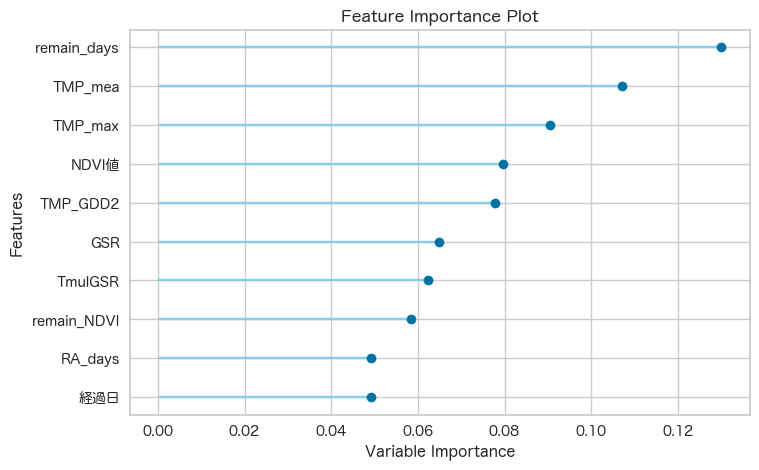

In [10]:
from matplotlib import rcParams
rcParams['font.family'] = 'sans-serif'
rcParams['font.sans-serif'] = ['Hiragino Maru Gothic Pro', 'Yu Gothic', 'Meirio']
plot_model(final_rfr, plot='feature')

# END